In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
!wget https://raw.githubusercontent.com/cedmenezes/estudos/refs/heads/main/titanic_data.csv

--2026-03-20 12:16:00--  https://raw.githubusercontent.com/cedmenezes/estudos/refs/heads/main/titanic_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic_data.csv’

titanic_data.csv    100%[===================>]  58.89K  --.-KB/s    in 0.005s  

2026-03-20 12:16:00 (12.7 MB/s) - ‘titanic_data.csv’ saved [60302/60302]



In [ ]:
# lendo titanic_data.csv
td = pd.read_csv('titanic_data.csv')

# Exibindo as colunas
td.columns


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
# identificar o tipo de cada variável
print(td.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


**Entendendo o significado dos dados:**

- PassengerId: Número de identificação do passageiro
- Survived: Informa se o passageiro sobreviveu ao desastre (0 = Não e 1 = Sim)
- Pclass: Classe do bilhete (1 = 1ª Classe, 2 = 2ª Classe e 3 = 3ª Classe)
- Name: Nome do passageiro
- Sex: Sexo do passageiro
- Age: Idade do passageiro
- SibSp: Quantidade de cônjuges e irmãos a bordo
- Parch: Quantidade de pais e filhos a bordo
- Ticket: Número da passagem
- Fare: Preço da Passagem
- Cabin: Número da cabine do passageiro
- Embarked: Porto no qual o passageiro embarcou (C = Cherbourg, Q = Queenstown e S = Southampton)

In [ ]:
# ver as 5 primeiras linhas dos dados
td.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
td.columns

# Excluindo as colunas ['PassengerId', 'Name', 'Ticket', 'Cabin']
td.drop(
    ['PassengerId', 'Name', 'Ticket', 'Cabin'],
    axis=1,  # coluna
    inplace=True  # faço alterações no DataFrame, ou seja, altero td
)

In [ ]:
# exibindo as colunas (features) relevantes que sobraram
td.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [ ]:
td.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# contando os valores faltantes

td.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


Nós percebemos que existem dados faltantes na coluna 'Age' (177) e na coluna 'Embarked' (apenas 2). Sem estes dados, não consigo construir um modelo.
Há algumas maneiras/técnicas para lidar com este problema:

1) Eliminar coluna com dado faltante
2) Eliminar as linhas em que faltam dados
3) Imputação: insiro dados sintéticos ("inventados"), baseados em estatísticas, no lugar dos dados faltantes.

In [ ]:
# Exibindo a média por classe
print (td.groupby('Pclass'). mean(numeric_only=True))

        Survived        Age     SibSp     Parch       Fare
Pclass                                                    
1       0.629630  38.233441  0.416667  0.356481  84.154687
2       0.472826  29.877630  0.402174  0.380435  20.662183
3       0.242363  25.140620  0.615071  0.393075  13.675550


In [ ]:
# criando função para inserir idade faltante
def insert_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):
        if Pclass == 1:
            return 38
        elif Pclass == 2:
            return 30
        else:
            return 25
    else:
        return Age


In [ ]:
# aplicando a função aos dataFrame
td['Age'] = td[['Age','Pclass']].apply(insert_age,axis=1)

/tmp/ipykernel_582/968722176.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Age = cols[0]
/tmp/ipykernel_582/968722176.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  Pclass = cols[1]


In [ ]:
td['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [ ]:
porto_mais_usado = td['Embarked'].value_counts().keys()[0]  # Porto mais usado
porto_mais_usado

'S'

In [ ]:
# embarked
td['Embarked'].fillna(porto_mais_usado, inplace=True)

/tmp/ipykernel_582/2654975310.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  td['Embarked'].fillna(porto_mais_usado, inplace=True)


In [ ]:
# contando os valores faltantes
td.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [ ]:
td.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,25.0,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


In [ ]:
# exibindo os tipos de dados
td.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
# criando o dataframe sex com a coluna 'Sex' convertida para valores numéricos
sex = pd.get_dummies(td['Sex'],drop_first=True)
print (sex)

      male
0     True
1    False
2    False
3    False
4     True
..     ...
886   True
887  False
888  False
889   True
890   True

[891 rows x 1 columns]


In [ ]:
# criando o dataframe embark com a coluna 'Embarked' convertida para valores numéricos
embark = pd.get_dummies(td['Embarked'],drop_first=True)
print (embark)


         Q      S
0    False   True
1    False  False
2    False   True
3    False   True
4    False   True
..     ...    ...
886  False   True
887  False   True
888  False   True
889  False  False
890   True  False

[891 rows x 2 columns]


In [ ]:
# Eliminando as colunas Sex e Embarked
td.drop(['Sex','Embarked'],axis=1,inplace=True)

In [ ]:
# concateno df com sex e embark
td = pd.concat([td,sex,embark],axis=1)


In [ ]:
# verificando o dataframe
td.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [ ]:
# exibindo os tipos de dados
td.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   male      891 non-null    bool   
 7   Q         891 non-null    bool   
 8   S         891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(td.drop('Survived',axis=1), td['Survived'], test_size=0.40, random_state=101)

In [ ]:
X_train

,Pclass,Age,SibSp,Parch,Fare,male,Q,S
124,1,54.0,0,1,77.2875,True,False,True
745,1,70.0,1,1,71.0000,True,False,True
653,3,25.0,0,0,7.8292,False,True,False
272,2,41.0,0,1,19.5000,False,False,True
868,3,25.0,0,0,9.5000,True,False,True
...,...,...,...,...,...,...,...,...
575,3,19.0,0,0,14.5000,True,False,True
838,3,32.0,0,0,56.4958,True,False,True
337,1,41.0,0,0,134.5000,False,False,False
523,1,44.0,0,1,57.9792,False,False,False


In [ ]:
y_test

,Survived
331,0
700,1
748,0
751,1
481,0
...,...
53,1
117,0
206,0
462,0


In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression(solver='lbfgs',max_iter=1000)

logmodel.fit(X_train,y_train)


LogisticRegression(max_iter=1000)

In [ ]:
predictions = logmodel.predict(X_test)
predictions

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       207
           1       0.80      0.67      0.73       150

    accuracy                           0.79       357
   macro avg       0.79      0.77      0.78       357
weighted avg       0.79      0.79      0.79       357



In [ ]:
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_test, predictions)
print(conf_mat)

[[181  26]
 [ 49 101]]


In [ ]:
import warnings
warnings.filterwarnings("ignore")
# Aplicação
# Pclass, Age, SibSp, Parch, Fare, male, Q, S
Rose_Vanessa  = np.array([2,34,0,1,50,0,0,0]).reshape((1,-1))

# resultado: 0 = não sobreviveu 1 = sobreviveu
resultado = logmodel.predict(Rose_Vanessa)[0]
print("Sobreviveu?:", "Sim" if resultado == 1 else "Não")
print(f"Probabilidade: {logmodel.predict_proba(Rose_Vanessa)[0][resultado]*100:.2f}%")

Sobreviveu?: Sim
Probabilidade: 82.78%


In [ ]:
# Aplicação
# Pclass, Age, SibSp, Parch, Fare, male, Q, S
Jack_Daniel  = np.array([1,47,0,0,90,1,0,1]).reshape((1,-1))

# resultado: 0 = não sobreviveu 1 = sobreviveu
resultado = logmodel.predict(Jack_Daniel)[0]
print("Sobreviveu?:", "Sim" if resultado == 1 else "Não")
print(f"Probabilidade: {logmodel.predict_proba(Jack_Daniel)[0][resultado]*100:.2f}%")

Sobreviveu?: Não
Probabilidade: 62.06%


In [ ]:
print (td.groupby('male'). mean()['Survived'])

male
False    0.742038
True     0.188908
Name: Survived, dtype: float64


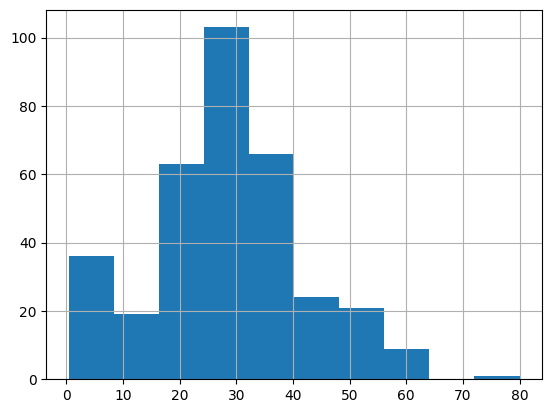

In [ ]:
td.query("Survived == 1")['Age'].hist();

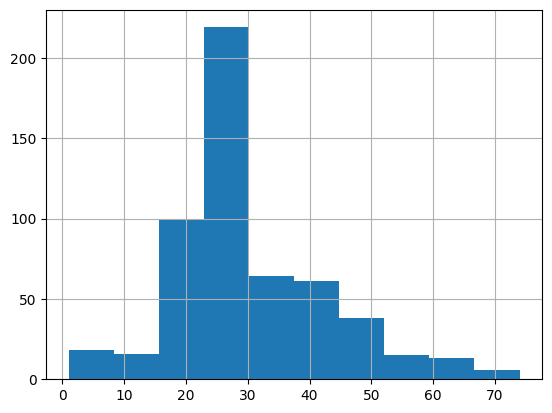

In [ ]:
td.query("Survived == 0")['Age'].hist();